# Faza 5 — baseline fine-tuning srpskog LipNet-a


## Goal

Fine-tune-uj preneti VIPL model na speaker-disjoint AI-SPEAK splitu. Prve tri
epohe uče samo novi srpski head, zatim se odmrzava ceo model. Najbolji checkpoint
bira se isključivo strogo manjim validation WER-om; test govornici se evaluiraju
tek nakon izbora modela.


## Setup

Izaberi **Runtime → Change runtime type → T4 GPU**. Notebook čuva `latest.pt`,
`best.pt`, istoriju i rezultate u `MyDrive/LipNet/phase5`, pa bezbedno nastavlja
rad posle prekida Colab sesije.


In [1]:
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'editdistance>=0.8.1', 'opencv-python-headless>=4.10',
     'nbformat>=5.10.4', 'pytest>=8.4'],
    check=True,
)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'editdistance>=0.8.1', 'opencv-python-headless>=4.10', 'nbformat>=5.10.4', 'pytest>=8.4'], returncode=0)

In [2]:
import os
import subprocess
from pathlib import Path

REPO_URL = 'https://github.com/nikolabakic/Vizuelno-prepoznavanje-govora-na-osnovu-pokreta-usana-pomo-u-LipNet-modela.git'
REPO = Path('/content/lipnet-serbian')
if not (REPO / 'lipnet').exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO)], check=True)
os.chdir(REPO)
print('Repo:', REPO)
print('Commit:', subprocess.check_output(['git', 'rev-parse', 'HEAD'], text=True).strip())


Repo: /content/lipnet-serbian
Commit: 25106e37a2bf91971f1350a4548fb9bb50581f79


In [3]:
import json
import random
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import torch

from lipnet.train import FineTuneConfig

assert torch.cuda.is_available(), 'Uključi T4 GPU u Colab Runtime postavkama.'
DEVICE = torch.device('cuda')
CONFIG = FineTuneConfig(
    max_epochs=30,
    warmup_epochs=3,
    early_stopping_patience=5,
    batch_size=2,
    backbone_lr=2e-5,
    head_lr=1e-4,
    num_workers=2,
    random_seed=0,
)
random.seed(CONFIG.random_seed)
np.random.seed(CONFIG.random_seed)
torch.manual_seed(CONFIG.random_seed)
torch.cuda.manual_seed_all(CONFIG.random_seed)
print('GPU:', torch.cuda.get_device_name(0))
print('Konfiguracija:', json.dumps(asdict(CONFIG), indent=2))


GPU: NVIDIA L4
Konfiguracija: {
  "max_epochs": 30,
  "warmup_epochs": 3,
  "early_stopping_patience": 5,
  "batch_size": 2,
  "backbone_lr": 2e-05,
  "head_lr": 0.0001,
  "num_workers": 2,
  "random_seed": 0
}


In [4]:
from google.colab import drive

drive.mount('/content/drive')
DRIVE_ROOT = Path('/content/drive/MyDrive/LipNet')
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
print('Drive izlaz:', DRIVE_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive izlaz: /content/drive/MyDrive/LipNet


In [5]:
PHASE5_DIR = DRIVE_ROOT / 'phase5'
PHASE5_DIR.mkdir(parents=True, exist_ok=True)
LATEST_CHECKPOINT = PHASE5_DIR / 'latest.pt'
BEST_CHECKPOINT = PHASE5_DIR / 'best.pt'
HISTORY_PATH = PHASE5_DIR / 'history.json'
RESULTS_PATH = PHASE5_DIR / 'results.json'
CURVES_PATH = PHASE5_DIR / 'training_curves.png'
print('Phase 5 izlaz:', PHASE5_DIR)


Phase 5 izlaz: /content/drive/MyDrive/LipNet/phase5


### 0. Pokreni CPU kompatibilnosne testove


In [6]:
subprocess.run(
    [sys.executable, '-m', 'pytest', '-q',
     'tests/test_vipl_phases.py', 'tests/test_phase5.py'],
    check=True,
)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pytest', '-q', 'tests/test_vipl_phases.py', 'tests/test_phase5.py'], returncode=0)

## Steps

### 1. Raspakuj mouth frejmove i ALIGN anotacije na lokalni disk


In [7]:
import zipfile

MOUTH_ARCHIVE = DRIVE_ROOT / 'ai_speak_lip.zip'
SOURCE_ARCHIVE = Path('/content/drive/MyDrive/processed.zip')  # promeni po potrebi
MOUTH_ROOT = Path('/content/ai_speak_lip')
ALIGN_EXTRACT = Path('/content/ai_speak_align')
assert MOUTH_ARCHIVE.exists(), MOUTH_ARCHIVE
assert SOURCE_ARCHIVE.exists(), SOURCE_ARCHIVE

if not next(MOUTH_ROOT.glob('spk*/video/video_a/*'), None):
    MOUTH_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(MOUTH_ARCHIVE) as archive:
        archive.extractall(MOUTH_ROOT)
if not next(ALIGN_EXTRACT.rglob('spk*/alignment/*.align'), None):
    ALIGN_EXTRACT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(SOURCE_ARCHIVE) as archive:
        members = [
            member for member in archive.infolist()
            if '/alignment/' in f'/{member.filename}'
            and member.filename.endswith('.align')
        ]
        archive.extractall(ALIGN_EXTRACT, members=members)
first_alignment = next(ALIGN_EXTRACT.rglob('spk*/alignment/*.align'))
CORPUS_ROOT = first_alignment.parents[2]
print('Mouth root:', MOUTH_ROOT)
print('Annotation root:', CORPUS_ROOT)


Mouth root: /content/ai_speak_lip
Annotation root: /content/ai_speak_align/processed


### 2. Formiraj splitove i runtime CTC filter bez manifesta


In [8]:
from torch.utils.data import DataLoader, Subset

from data.splits import (
    SPLITS, TEST_SPEAKERS, TRAIN_SPEAKERS, VALIDATION_SPEAKERS,
)
from lipnet.dataset import SerbianDataset, variable_length_collate
from lipnet.train import scan_ctc_compatibility

raw_datasets = {
    'train': SerbianDataset(MOUTH_ROOT, CORPUS_ROOT, TRAIN_SPEAKERS, phase='train'),
    'validation': SerbianDataset(
        MOUTH_ROOT, CORPUS_ROOT, VALIDATION_SPEAKERS, phase='validation'
    ),
    'test': SerbianDataset(MOUTH_ROOT, CORPUS_ROOT, TEST_SPEAKERS, phase='test'),
}
ctc_reports = {
    name: scan_ctc_compatibility(dataset)
    for name, dataset in raw_datasets.items()
}
datasets = {
    name: Subset(raw_datasets[name], report.valid_indices)
    for name, report in ctc_reports.items()
}
for name, report in ctc_reports.items():
    print(
        f'{name:10s}: valid={report.valid_count}, '
        f'CTC-odbačeno={report.invalid_count}'
    )

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_loader(name, *, epoch=0, shuffle=False):
    generator = torch.Generator()
    generator.manual_seed(CONFIG.random_seed + epoch)
    return DataLoader(
        datasets[name],
        batch_size=CONFIG.batch_size,
        shuffle=shuffle,
        num_workers=CONFIG.num_workers,
        collate_fn=variable_length_collate,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=generator,
        persistent_workers=False,
    )


train     : valid=2877, CTC-odbačeno=0
validation: valid=540, CTC-odbačeno=0
test      : valid=540, CTC-odbačeno=0


### 3. Učitaj transfer ili automatski nastavi `latest.pt`


In [9]:
from urllib.request import urlretrieve

from lipnet.dataset import SERBIAN_LETTERS
from lipnet.model import LipNet
from lipnet.train import (
    build_finetune_optimizer, greedy_decode, load_training_checkpoint,
    load_vipl_transfer, set_backbone_trainable,
)

UPSTREAM_SHA = '40209e09c49553c00c25c7d41faa3706aea3c625'
VIPL_CHECKPOINT = Path('/content') / 'LipNet_unseen_loss_0.44562849402427673_wer_0.1332580699113564_cer_0.06796452465503355.pt'
VIPL_CHECKPOINT_URL = (
    'https://raw.githubusercontent.com/VIPL-Audio-Visual-Speech-Understanding/'
    f'LipNet-PyTorch/{UPSTREAM_SHA}/pretrain/LipNet_unseen_loss_0.44562849402427673_wer_0.1332580699113564_cer_0.06796452465503355.pt'
)
if not VIPL_CHECKPOINT.exists():
    urlretrieve(VIPL_CHECKPOINT_URL, VIPL_CHECKPOINT)

NUM_CLASSES = 1 + len(SERBIAN_LETTERS)
assert NUM_CLASSES == 29
model = LipNet(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = build_finetune_optimizer(
    model, backbone_lr=CONFIG.backbone_lr, head_lr=CONFIG.head_lr
)

if LATEST_CHECKPOINT.exists():
    state = load_training_checkpoint(LATEST_CHECKPOINT, model, optimizer)
    assert state.config == asdict(CONFIG), (
        'Resume konfiguracija se razlikuje od CONFIG ćelije: '
        f'checkpoint={state.config} current={asdict(CONFIG)}'
    )
    start_epoch = state.next_epoch
    best_val_wer = state.best_val_wer
    best_epoch = state.best_epoch
    epochs_without_improvement = state.epochs_without_improvement
    history = list(state.history)
    audit = None
    print('Nastavljam od epohe', start_epoch + 1)
else:
    audit = load_vipl_transfer(model, VIPL_CHECKPOINT)
    assert set(audit.skipped_shape) == {'FC.weight', 'FC.bias'}
    assert not audit.missing_in_checkpoint and not audit.unexpected_in_checkpoint
    start_epoch = 0
    best_val_wer = float('inf')
    best_epoch = -1
    epochs_without_improvement = 0
    history = []
    print('Novi trening:', audit.summary())

set_backbone_trainable(model, start_epoch >= CONFIG.warmup_epochs)


Nastavljam od epohe 31


('conv1.weight',
 'conv1.bias',
 'conv2.weight',
 'conv2.bias',
 'conv3.weight',
 'conv3.bias',
 'gru1.weight_ih_l0',
 'gru1.weight_hh_l0',
 'gru1.bias_ih_l0',
 'gru1.bias_hh_l0',
 'gru1.weight_ih_l0_reverse',
 'gru1.weight_hh_l0_reverse',
 'gru1.bias_ih_l0_reverse',
 'gru1.bias_hh_l0_reverse',
 'gru2.weight_ih_l0',
 'gru2.weight_hh_l0',
 'gru2.bias_ih_l0',
 'gru2.bias_hh_l0',
 'gru2.weight_ih_l0_reverse',
 'gru2.weight_hh_l0_reverse',
 'gru2.bias_ih_l0_reverse',
 'gru2.bias_hh_l0_reverse',
 'FC.weight',
 'FC.bias')

### 4. Treniraj, validiraj i čuvaj latest/best checkpoint


In [11]:
from lipnet.train import (
    run_epoch, save_training_checkpoint, validation_wer_improved,
)

checkpoint_metadata = {
    'phase': 5,
    'upstream_commit': UPSTREAM_SHA,
    'num_classes': NUM_CLASSES,
    'speakers': {name: list(value) for name, value in SPLITS.items()},
    'ctc_filter': {
        name: {'valid': report.valid_count, 'invalid': report.invalid_count}
        for name, report in ctc_reports.items()
    },
}

for epoch in range(start_epoch, CONFIG.max_epochs):
    backbone_trainable = epoch >= CONFIG.warmup_epochs
    set_backbone_trainable(model, backbone_trainable)
    train_result = run_epoch(
        model,
        make_loader('train', epoch=epoch, shuffle=True),
        DEVICE,
        optimizer,
    )
    validation_result = run_epoch(
        model, make_loader('validation'), DEVICE
    )
    improved = validation_wer_improved(validation_result.wer, best_val_wer)
    if improved:
        best_val_wer = validation_result.wer
        best_epoch = epoch

    if epoch < CONFIG.warmup_epochs:
        epochs_without_improvement = 0
    elif improved:
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    record = {
        'epoch': epoch,
        'stage': 'full' if backbone_trainable else 'head_only',
        'train': train_result.metrics(),
        'validation': validation_result.metrics(),
    }
    history.append(record)
    checkpoint_arguments = dict(
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        best_val_wer=best_val_wer,
        best_epoch=best_epoch,
        epochs_without_improvement=epochs_without_improvement,
        history=history,
        config=CONFIG,
        metadata=checkpoint_metadata,
    )
    if improved:
        save_training_checkpoint(BEST_CHECKPOINT, **checkpoint_arguments)
    save_training_checkpoint(LATEST_CHECKPOINT, **checkpoint_arguments)
    HISTORY_PATH.write_text(
        json.dumps(history, indent=2, ensure_ascii=False) + '\n',
        encoding='utf-8',
    )

    print(
        f'Epoha {{epoch + 1:02d}}/{{CONFIG.max_epochs}} '
        f'[{{record["stage"]}}] '
        f'train loss={{train_result.loss:.4f}} WER={{train_result.wer:.4f}} | '
        f'val loss={{validation_result.loss:.4f}} '
        f'WER={{validation_result.wer:.4f}} CER={{validation_result.cer:.4f}} '
        f'exact={{validation_result.sentence_exact_match:.4f}}'
        + ('  *BEST*' if improved else '')
    )
    if (
        epoch >= CONFIG.warmup_epochs
        and epochs_without_improvement >= CONFIG.early_stopping_patience
    ):
        print('Early stopping: validation WER se nije poboljšao.')
        break

assert BEST_CHECKPOINT.exists(), 'Nije sačuvan najbolji checkpoint.'
print('Najbolja epoha:', best_epoch + 1, 'validation WER:', best_val_wer)


Epoha {epoch + 1:02d}/{CONFIG.max_epochs} [{record["stage"]}] train loss={train_result.loss:.4f} WER={train_result.wer:.4f} | val loss={validation_result.loss:.4f} WER={validation_result.wer:.4f} CER={validation_result.cer:.4f} exact={validation_result.sentence_exact_match:.4f}  *BEST*
Epoha {epoch + 1:02d}/{CONFIG.max_epochs} [{record["stage"]}] train loss={train_result.loss:.4f} WER={train_result.wer:.4f} | val loss={validation_result.loss:.4f} WER={validation_result.wer:.4f} CER={validation_result.cer:.4f} exact={validation_result.sentence_exact_match:.4f}  *BEST*
Epoha {epoch + 1:02d}/{CONFIG.max_epochs} [{record["stage"]}] train loss={train_result.loss:.4f} WER={train_result.wer:.4f} | val loss={validation_result.loss:.4f} WER={validation_result.wer:.4f} CER={validation_result.cer:.4f} exact={validation_result.sentence_exact_match:.4f}  *BEST*
Epoha {epoch + 1:02d}/{CONFIG.max_epochs} [{record["stage"]}] train loss={train_result.loss:.4f} WER={train_result.wer:.4f} | val loss={val

In [10]:
from pathlib import Path

from lipnet.model import LipNet
from lipnet.train import (
    build_strong_finetune_optimizer,
    set_backbone_trainable,
)

STRONG_DIR = DRIVE_ROOT / "strong_finetune"
STRONG_DIR.mkdir(parents=True, exist_ok=True)

STRONG_LATEST = STRONG_DIR / "latest.pt"
STRONG_BEST = STRONG_DIR / "best.pt"

STRONG_MAX_EPOCHS = 70
STRONG_PATIENCE = 12
ACCUMULATION_STEPS = 4
GRAD_CLIP_NORM = 5.0

model = LipNet(num_classes=NUM_CLASSES).to(DEVICE)

payload = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)
model.load_state_dict(payload["model_state_dict"], strict=True)

set_backbone_trainable(model, True)

optimizer = build_strong_finetune_optimizer(model)

print("Učitan Phase 5 best checkpoint.")
print("Početni validation WER:", payload["best_val_wer"])

Učitan Phase 5 best checkpoint.
Početni validation WER: 0.590432098765432


In [12]:
from lipnet.train import (
    run_epoch,
    build_strong_finetune_optimizer,
    set_backbone_trainable,
)

In [14]:
import inspect

print(inspect.signature(run_epoch))

(model: 'nn.Module', loader: 'Any', device: 'torch.device', optimizer: 'Optimizer | None' = None, criterion: 'nn.CTCLoss | None' = None, accumulation_steps: 'int' = 1, grad_clip_norm: 'float | None' = None) -> 'EpochResult'


In [15]:
import math

best_val_wer = float("inf")
best_epoch = -1
epochs_without_improvement = 0
history = []


def update_learning_rates(
    optimizer: torch.optim.Optimizer,
    epoch: int,
    max_epochs: int,
) -> None:
    progress = epoch / max(max_epochs - 1, 1)

    cosine_scale = 0.1 + 0.9 * (
        0.5 * (1.0 + math.cos(math.pi * progress))
    )

    for group in optimizer.param_groups:
        group["lr"] = group["initial_lr"] * cosine_scale


for epoch in range(STRONG_MAX_EPOCHS):
    update_learning_rates(
        optimizer,
        epoch,
        STRONG_MAX_EPOCHS,
    )

    train_result = run_epoch(
        model,
        make_loader("train", epoch=epoch, shuffle=True),
        DEVICE,
        optimizer,
        accumulation_steps=ACCUMULATION_STEPS,
        grad_clip_norm=GRAD_CLIP_NORM,
    )

    validation_result = run_epoch(
        model,
        make_loader("validation"),
        DEVICE,
    )

    improved = validation_result.wer < best_val_wer

    if improved:
        best_val_wer = validation_result.wer
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_wer": best_val_wer,
            },
            STRONG_BEST,
        )
    else:
        epochs_without_improvement += 1

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "best_val_wer": best_val_wer,
        },
        STRONG_LATEST,
    )

    current_lrs = {
        group["name"]: group["lr"]
        for group in optimizer.param_groups
    }

    history.append(
        {
            "epoch": epoch + 1,
            "train": train_result.metrics(),
            "validation": validation_result.metrics(),
            "learning_rates": current_lrs,
        }
    )

    print(
        f"Epoch {epoch + 1:02d}/{STRONG_MAX_EPOCHS} | "
        f"train WER={train_result.wer:.4f} | "
        f"val WER={validation_result.wer:.4f} "
        f"CER={validation_result.cer:.4f}"
        + ("  *BEST*" if improved else "")
    )

    if epochs_without_improvement >= STRONG_PATIENCE:
        print("Early stopping.")
        break

print(
    "Best epoch:",
    best_epoch + 1,
    "validation WER:",
    best_val_wer,
)

Epoch 01/70 | train WER=0.5668 | val WER=0.5790 CER=0.2225  *BEST*
Epoch 02/70 | train WER=0.5584 | val WER=0.5728 CER=0.2182  *BEST*
Epoch 03/70 | train WER=0.5527 | val WER=0.5769 CER=0.2182
Epoch 04/70 | train WER=0.5507 | val WER=0.5778 CER=0.2214
Epoch 05/70 | train WER=0.5465 | val WER=0.5707 CER=0.2206  *BEST*
Epoch 06/70 | train WER=0.5429 | val WER=0.5707 CER=0.2169  *BEST*
Epoch 07/70 | train WER=0.5370 | val WER=0.5586 CER=0.2108  *BEST*
Epoch 08/70 | train WER=0.5315 | val WER=0.5642 CER=0.2148
Epoch 09/70 | train WER=0.5261 | val WER=0.5577 CER=0.2131  *BEST*
Epoch 10/70 | train WER=0.5203 | val WER=0.5630 CER=0.2189
Epoch 11/70 | train WER=0.5217 | val WER=0.5540 CER=0.2100  *BEST*
Epoch 12/70 | train WER=0.5188 | val WER=0.5568 CER=0.2153
Epoch 13/70 | train WER=0.5138 | val WER=0.5586 CER=0.2168
Epoch 14/70 | train WER=0.5137 | val WER=0.5614 CER=0.2189
Epoch 15/70 | train WER=0.5105 | val WER=0.5506 CER=0.2102  *BEST*
Epoch 16/70 | train WER=0.5041 | val WER=0.5593 CER

### 5. Prikaži i sačuvaj krive treniranja


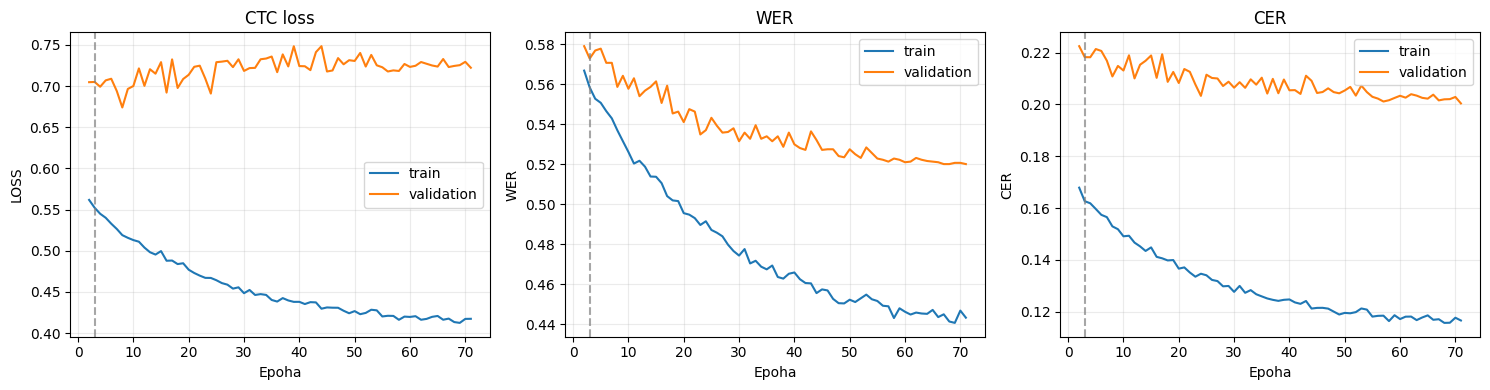

In [19]:
epochs = [item['epoch'] + 1 for item in history]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, metric, title in zip(
    axes, ('loss', 'wer', 'cer'), ('CTC loss', 'WER', 'CER')
):
    axis.plot(epochs, [item['train'][metric] for item in history], label='train')
    axis.plot(
        epochs,
        [item['validation'][metric] for item in history],
        label='validation',
    )
    axis.axvline(CONFIG.warmup_epochs, color='gray', linestyle='--', alpha=0.7)
    axis.set(title=title, xlabel='Epoha', ylabel=metric.upper())
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
fig.savefig(CURVES_PATH, dpi=160, bbox_inches='tight')
plt.show()


## Checks

### 6. Učitaj `best.pt` i evaluiraj neviđene test govornike jednom


In [21]:
import hashlib
import json
import torch

# Učitaj najbolji strong-finetuning checkpoint
checkpoint = torch.load(
    STRONG_BEST,
    map_location="cpu",
    weights_only=False,
)

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)

model = model.to(DEVICE)

best_epoch = int(checkpoint["epoch"])
best_validation_wer = float(checkpoint["best_val_wer"])

print("Učitan strong best checkpoint")
print("Best epoch:", best_epoch + 1)
print("Best validation WER:", best_validation_wer)

# Hash checkpointa
checkpoint_hasher = hashlib.sha256()

with STRONG_BEST.open("rb") as checkpoint_file:
    for chunk in iter(
        lambda: checkpoint_file.read(1024 * 1024),
        b"",
    ):
        checkpoint_hasher.update(chunk)

best_checkpoint_sha256 = checkpoint_hasher.hexdigest()
FORCE_TEST_REEVALUATION = False

previous_results = None

if RESULTS_PATH.exists():
    previous_results = json.loads(
        RESULTS_PATH.read_text(encoding="utf-8")
    )

if (
    previous_results is not None
    and previous_results.get("best_epoch") == best_epoch + 1
    and previous_results.get("best_checkpoint_sha256") == best_checkpoint_sha256
    and not FORCE_TEST_REEVALUATION
):
    results = previous_results
    print("Koristim već sačuvanu test evaluaciju za isti strong best checkpoint.")

else:
    test_result = run_epoch(
        model,
        make_loader("test"),
        DEVICE,
    )

    qualitative = [
        {
            "reference": reference,
            "prediction": prediction,
        }
        for reference, prediction in list(
            zip(
                test_result.references,
                test_result.predictions,
            )
        )[:10]
    ]

    results = {
        "phase": "strong_finetune",
        "best_epoch": best_epoch + 1,
        "best_validation_wer": best_validation_wer,
        "best_checkpoint_sha256": best_checkpoint_sha256,
        "test": test_result.metrics(),
        "test_samples": test_result.samples,
        "qualitative": qualitative,
    }

    RESULTS_PATH.write_text(
        json.dumps(
            results,
            indent=2,
            ensure_ascii=False,
        ) + "\n",
        encoding="utf-8",
    )

print(
    json.dumps(
        {
            "best_epoch": results["best_epoch"],
            "best_validation_wer": results["best_validation_wer"],
            "test": results["test"],
            "test_samples": results["test_samples"],
        },
        indent=2,
        ensure_ascii=False,
    )
)

for item in results["qualitative"]:
    print("REF :", item["reference"])
    print("PRED:", item["prediction"])
    print()

Učitan strong best checkpoint
Best epoch: 66
Best validation WER: 0.5200617283950617
{
  "best_epoch": 66,
  "best_validation_wer": 0.5200617283950617,
  "test": {
    "loss": 0.5715362275088275,
    "wer": 0.47222222222222215,
    "cer": 0.16367445495476837,
    "sentence_exact_match": 0.0
  },
  "test_samples": 540
}
REF : obriši d levo i nedelja dva
PRED: obriši m desno p nedelja dva

REF : dalje z dole i četvrtak devet
PRED: dalje d dole d edelja šest

REF : kraj r desno j sreda devet
PRED: kraj d desno psreda devt

REF : dalje z levo r ponedeljak osam
PRED: dalje b levo p onedeljak osam

REF : pošalji lj levo g četvrtak četiri
PRED: pošalji l levo v četvrtak čtiri

REF : odustani k desno m subota dva
PRED: odustani h devo o ubota dva

REF : odustani h dole a ponedeljak četiri
PRED: odustani g gore f edeljak četiri

REF : početak f napred o subota sedam
PRED: pošalji n napred p ubota jedan

REF : kraj e levo b sreda jedan
PRED: dalje d levo p petak devt

REF : potvrdi d desno l pon

### 7. Potvrdi checkpoint round-trip i inference ugovor


In [23]:
reloaded_model = LipNet(num_classes=NUM_CLASSES).to(DEVICE)

strong_checkpoint = torch.load(
    STRONG_BEST,
    map_location="cpu",
    weights_only=False,
)

reloaded_model.load_state_dict(
    strong_checkpoint["model_state_dict"],
    strict=True,
)

inference_batch = next(iter(make_loader("test")))

reloaded_model.eval()

with torch.no_grad():
    inference_logits = reloaded_model(
        inference_batch["vid"].to(DEVICE)
    )

inference_text = greedy_decode(
    inference_logits,
    output_lengths=inference_batch["vid_len"],
)

assert len(inference_text) == inference_batch["vid"].shape[0]

assert strong_checkpoint["epoch"] + 1 == results["best_epoch"]

print(
    "PASS: strong best checkpoint se ponovo učitava i daje inference:",
    inference_text,
)

PASS: strong best checkpoint se ponovo učitava i daje inference: ['obriši m desno p nedelja dva', 'dalje d dole d edelja šest']


In [25]:
from collections import defaultdict, Counter
from lipnet.train import reference_text

train_loader = make_loader("train", shuffle=False)

train_sentences = []

for batch in train_loader:
    train_sentences.extend(
        reference_text(batch)
    )

print("Broj train rečenica:", len(train_sentences))

length_counts = Counter(
    len(sentence.split())
    for sentence in train_sentences
)

print("Broj reči po rečenici:")
print(length_counts)

words_by_position = defaultdict(Counter)

for sentence in train_sentences:
    words = sentence.split()

    for position, word in enumerate(words):
        words_by_position[position][word] += 1

for position in sorted(words_by_position):
    vocabulary = sorted(words_by_position[position])

    print()
    print(
        f"POZICIJA {position + 1} "
        f"({len(vocabulary)} različitih vrednosti)"
    )
    print(vocabulary)

Broj train rečenica: 2877
Broj reči po rečenici:
Counter({6: 2877})

POZICIJA 1 (7 različitih vrednosti)
['dalje', 'kraj', 'obriši', 'odustani', 'potvrdi', 'početak', 'pošalji']

POZICIJA 2 (30 različitih vrednosti)
['a', 'b', 'c', 'd', 'dž', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'lj', 'm', 'n', 'nj', 'o', 'p', 'r', 's', 't', 'u', 'v', 'z', 'ć', 'č', 'đ', 'š', 'ž']

POZICIJA 3 (6 različitih vrednosti)
['desno', 'dole', 'gore', 'levo', 'napred', 'nazad']

POZICIJA 4 (30 različitih vrednosti)
['a', 'b', 'c', 'd', 'dž', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'lj', 'm', 'n', 'nj', 'o', 'p', 'r', 's', 't', 'u', 'v', 'z', 'ć', 'č', 'đ', 'š', 'ž']

POZICIJA 5 (7 različitih vrednosti)
['nedelja', 'petak', 'ponedeljak', 'sreda', 'subota', 'utorak', 'četvrtak']

POZICIJA 6 (10 različitih vrednosti)
['devet', 'dva', 'jedan', 'nula', 'osam', 'pet', 'sedam', 'tri', 'četiri', 'šest']


In [26]:
!pip install https://github.com/kpu/kenlm/archive/master.zip

     \ 553.6 kB 352.1 kB/s 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for kenlm: filename=kenlm-0.2.0-cp312-cp312-linux_x86_64.whl size=3188042 sha256=71509fa125f14618e6f58625cff57decaa490328dc4cdb57d7d1bbcac61b3ac7
  Stored in directory: /tmp/pip-ephem-wheel-cache-nx15psuw/wheels/92/c8/12/56d187154e078f0eaa74d059017fc1afe1c4d91fbce02ce8d9
Successfully built kenlm


In [27]:
from pathlib import Path
from lipnet.train import reference_text

LM_DIR = STRONG_DIR / "lm"
LM_DIR.mkdir(parents=True, exist_ok=True)

LM_CORPUS = LM_DIR / "train_chars.txt"

train_sentences = []

for batch in make_loader("train", shuffle=False):
    train_sentences.extend(reference_text(batch))


def sentence_to_char_lm(sentence):
    return " ".join(
        "<sp>" if char == " " else char
        for char in sentence
    )


with LM_CORPUS.open("w", encoding="utf-8") as f:
    for sentence in train_sentences:
        f.write(sentence_to_char_lm(sentence) + "\n")

print("Rečenice:", len(train_sentences))
print("Corpus:", LM_CORPUS)

for sentence in train_sentences[:3]:
    print(sentence)
    print(sentence_to_char_lm(sentence))
    print()

Rečenice: 2877
Corpus: /content/drive/MyDrive/LipNet/strong_finetune/lm/train_chars.txt
dalje j levo o petak četiri
d a l j e <sp> j <sp> l e v o <sp> o <sp> p e t a k <sp> č e t i r i

kraj e napred š četvrtak jedan
k r a j <sp> e <sp> n a p r e d <sp> š <sp> č e t v r t a k <sp> j e d a n

kraj dž desno h ponedeljak pet
k r a j <sp> d ž <sp> d e s n o <sp> h <sp> p o n e d e l j a k <sp> p e t



In [28]:
%cd /content

!git clone https://github.com/kpu/kenlm.git
!apt-get -qq update
!apt-get -qq install -y libboost-all-dev libeigen3-dev zlib1g-dev libbz2-dev liblzma-dev

%cd /content/kenlm
!mkdir -p build
%cd build
!cmake ..
!make -j2

/content
Cloning into 'kenlm'...
remote: Enumerating objects: 14185, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 14185 (delta 117), reused 81 (delta 81), pack-reused 14009 (from 2)
Receiving objects: 100% (14185/14185), 5.91 MiB | 1.78 MiB/s, done.
Resolving deltas: 100% (8059/8059), done.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Selecting previously unselected package javascript-common.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../000-javascript-common_11+nmu1_all.deb ...
Unpacking javascript-common (11+nmu1) ...
Selecting previously unselected package libboost1.74-tools-dev.
Preparing to unpack .../001-libboost1.74-tools-dev_1.74.0-14ubuntu3_amd64.deb ...
Unpacking libboost1.

In [29]:
KENLM_BUILD = Path("/content/kenlm/build")
LM_ARPA = LM_DIR / "char_5gram.arpa"

!{KENLM_BUILD}/bin/lmplz \
    -o 5 \
    --text {LM_CORPUS} \
    --arpa {LM_ARPA} \
    --discount_fallback

=== 1/5 Counting and sorting n-grams ===
Reading /content/drive/MyDrive/LipNet/strong_finetune/lm/train_chars.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 83506 types 31
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:372 2:4438113792 3:8321463808 4:13314340864 5:19416748032
Substituting fallback discounts for order 3: D1=0.5 D2=1 D3+=1.5
Statistics:
1 31 D1=0.384615 D2=0.846154 D3+=1.07692
2 142 D1=0.647059 D2=1.35294 D3+=1.15126
3 499 D1=0.672811 D2=0.834426 D3+=0.440036
4 1261 D1=0.5 D2=1 D3+=1.5
5 2481 D1=0.232653 D2=1.25749 D3+=2.28343
Memory estimate for binary LM:
type     kB
probing  88 assuming -p 1.5
probing 100 assuming -r models -p 1.5
trie     30 without quantization
trie     19 assuming -q 8 -b 8 quantization 
trie     29 assuming -a 22 array pointer compression
trie     18 assumi

In [30]:
print("ARPA postoji:", LM_ARPA.exists())
print("Veličina:", LM_ARPA.stat().st_size / 1024, "KB")

ARPA postoji: True
Veličina: 127.49609375 KB


In [31]:
LM_BINARY = LM_DIR / "char_5gram.bin"

!{KENLM_BUILD}/bin/build_binary \
    {LM_ARPA} \
    {LM_BINARY}

print("Binary postoji:", LM_BINARY.exists())

Reading /content/drive/MyDrive/LipNet/strong_finetune/lm/char_5gram.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS
Binary postoji: True


In [32]:
import sys

sys.path.insert(0, "/content/kenlm/build/python")

import kenlm

lm = kenlm.Model(str(LM_BINARY))

print("Order:", lm.order)

examples = [
    "p o š a lj i <sp> a <sp> l e v o",
    "p o š a lj i <sp> a <sp> x x x",
]

for text in examples:
    print(text)
    print("score:", lm.score(text, bos=True, eos=True))
    print()

Order: 5
p o š a lj i <sp> a <sp> l e v o
score: -14.758180618286133

p o š a lj i <sp> a <sp> x x x
score: -20.24309730529785



In [33]:
import math
import torch
import kenlm

from lipnet.dataset import SERBIAN_LETTERS, BLANK_ID

LOG_ZERO = float("-inf")
LN10 = math.log(10.0)

CTC_CHARS = tuple(SERBIAN_LETTERS)

assert BLANK_ID == 0
assert len(CTC_CHARS) + 1 == NUM_CLASSES

print("Blank:", BLANK_ID)
print("CTC chars:", CTC_CHARS)
print("Classes:", NUM_CLASSES)

Blank: 0
CTC chars: (' ', 'a', 'b', 'c', 'č', 'ć', 'd', 'đ', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 'š', 't', 'u', 'v', 'z', 'ž')
Classes: 29


In [34]:
def log_add(a, b):
    if a == LOG_ZERO:
        return b
    if b == LOG_ZERO:
        return a

    maximum = max(a, b)

    return maximum + math.log(
        math.exp(a - maximum)
        + math.exp(b - maximum)
    )


def char_to_lm_token(char):
    return "<sp>" if char == " " else char


def new_lm_state(lm):
    state = kenlm.State()
    lm.BeginSentenceWrite(state)
    return state


def extend_lm(lm, state, char):
    next_state = kenlm.State()

    # KenLM vraća log10 score.
    log10_score = lm.BaseScore(
        state,
        char_to_lm_token(char),
        next_state,
    )

    # Pretvaramo u natural log da bude kompatibilno
    # sa torch.log_softmax CTC score-om.
    ln_score = log10_score * LN10

    return next_state, ln_score


def finish_lm(lm, state):
    next_state = kenlm.State()

    log10_score = lm.BaseScore(
        state,
        "</s>",
        next_state,
    )

    return log10_score * LN10

In [35]:
def ctc_prefix_beam_decode_with_lm(
    logits,
    output_length,
    lm,
    beam_width=100,
    alpha=1.0,
    beta=1.5,
):
    """
    CTC prefix beam search + character n-gram LM.

    alpha:
        težina language modela

    beta:
        word insertion bonus

    beam_width:
        broj hipoteza koje zadržavamo
    """

    log_probs = torch.log_softmax(
        logits[:output_length],
        dim=-1,
    ).detach().cpu()

    initial_state = new_lm_state(lm)

    # prefix -> {
    #     pb:   CTC log-prob koji završava blankom
    #     pnb:  CTC log-prob koji završava non-blank tokenom
    #     lm_state
    #     lm_score
    #     words
    # }
    beams = {
        (): {
            "pb": 0.0,
            "pnb": LOG_ZERO,
            "lm_state": initial_state,
            "lm_score": 0.0,
            "words": 0,
        }
    }

    for timestep in range(log_probs.shape[0]):

        next_beams = {}

        for prefix, beam in beams.items():

            pb = beam["pb"]
            pnb = beam["pnb"]

            total_ctc = log_add(pb, pnb)

            # -----------------------------
            # 1. BLANK
            # -----------------------------

            blank_score = (
                total_ctc
                + float(log_probs[timestep, BLANK_ID])
            )

            if prefix not in next_beams:
                next_beams[prefix] = {
                    "pb": LOG_ZERO,
                    "pnb": LOG_ZERO,
                    "lm_state": beam["lm_state"],
                    "lm_score": beam["lm_score"],
                    "words": beam["words"],
                }

            next_beams[prefix]["pb"] = log_add(
                next_beams[prefix]["pb"],
                blank_score,
            )

            # -----------------------------
            # 2. CHARACTERS
            # -----------------------------

            for token_id, char in enumerate(
                CTC_CHARS,
                start=1,
            ):

                char_score = float(
                    log_probs[timestep, token_id]
                )

                last_token = (
                    prefix[-1]
                    if prefix
                    else None
                )

                # --------------------------------
                # isti token kao prethodni
                # --------------------------------

                if last_token == token_id:

                    # CTC repeat bez blank-a:
                    # prefix se NE menja.
                    same_score = pnb + char_score

                    next_beams[prefix]["pnb"] = log_add(
                        next_beams[prefix]["pnb"],
                        same_score,
                    )

                    # Ako dolazimo iz blank-a,
                    # isti char može postati NOVI karakter.
                    extension_ctc = pb + char_score

                else:

                    extension_ctc = (
                        total_ctc + char_score
                    )

                if extension_ctc == LOG_ZERO:
                    continue

                new_prefix = prefix + (token_id,)

                if new_prefix not in next_beams:

                    new_lm_state_value, lm_delta = extend_lm(
                        lm,
                        beam["lm_state"],
                        char,
                    )

                    words = (
                        beam["words"] + 1
                        if char == " "
                        else beam["words"]
                    )

                    next_beams[new_prefix] = {
                        "pb": LOG_ZERO,
                        "pnb": LOG_ZERO,
                        "lm_state": new_lm_state_value,
                        "lm_score": (
                            beam["lm_score"]
                            + lm_delta
                        ),
                        "words": words,
                    }

                next_beams[new_prefix]["pnb"] = log_add(
                    next_beams[new_prefix]["pnb"],
                    extension_ctc,
                )

        # ----------------------------------
        # Beam pruning
        # ----------------------------------

        def beam_score(item):
            prefix, beam = item

            acoustic = log_add(
                beam["pb"],
                beam["pnb"],
            )

            return (
                acoustic
                + alpha * beam["lm_score"]
                + beta * beam["words"]
            )

        best = sorted(
            next_beams.items(),
            key=beam_score,
            reverse=True,
        )[:beam_width]

        beams = dict(best)

    # --------------------------------------
    # final score + EOS
    # --------------------------------------

    final_candidates = []

    for prefix, beam in beams.items():

        acoustic = log_add(
            beam["pb"],
            beam["pnb"],
        )

        eos_score = finish_lm(
            lm,
            beam["lm_state"],
        )

        # Ako postoji tekst bez trailing space-a,
        # računamo i poslednju reč.
        final_words = beam["words"]

        if prefix:
            final_char = CTC_CHARS[
                prefix[-1] - 1
            ]

            if final_char != " ":
                final_words += 1

        score = (
            acoustic
            + alpha * (
                beam["lm_score"]
                + eos_score
            )
            + beta * final_words
        )

        text = "".join(
            CTC_CHARS[token_id - 1]
            for token_id in prefix
        ).strip()

        final_candidates.append(
            (score, text)
        )

    final_candidates.sort(
        key=lambda item: item[0],
        reverse=True,
    )

    return final_candidates[0][1]

In [36]:
model = LipNet(
    num_classes=NUM_CLASSES
).to(DEVICE)

checkpoint = torch.load(
    STRONG_BEST,
    map_location="cpu",
    weights_only=False,
)

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)

model.eval()

LipNet(
  (conv1): Conv3d(3, 32, kernel_size=(3, 5, 5), stride=(1, 2, 2), padding=(1, 2, 2))
  (pool1): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv3d(32, 64, kernel_size=(3, 5, 5), stride=(1, 1, 1), padding=(1, 2, 2))
  (pool2): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv3d(64, 96, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (pool3): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (gru1): GRU(3072, 256, bidirectional=True)
  (gru2): GRU(512, 256, bidirectional=True)
  (FC): Linear(in_features=512, out_features=29, bias=True)
  (relu): ReLU(inplace=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (dropout3d): Dropout3d(p=0.5, inplace=False)
)

In [37]:
from lipnet.train import reference_text

validation_batch = next(
    iter(make_loader("validation"))
)

with torch.no_grad():
    validation_logits = model(
        validation_batch["vid"].to(DEVICE)
    )

references = reference_text(
    validation_batch
)

greedy_predictions = greedy_decode(
    validation_logits,
    output_lengths=validation_batch["vid_len"],
)

beam_predictions = []

for i in range(validation_logits.shape[0]):

    prediction = ctc_prefix_beam_decode_with_lm(
        validation_logits[i],
        output_length=int(
            validation_batch["vid_len"][i]
        ),
        lm=lm,
        beam_width=100,
        alpha=1.0,
        beta=1.5,
    )

    beam_predictions.append(prediction)

for ref, greedy, beam in zip(
    references,
    greedy_predictions,
    beam_predictions,
):
    print("REF   :", ref)
    print("GREEDY:", greedy)
    print("BEAM  :", beam)
    print()

REF   : početak s dole ć četvrtak sedam
GREEDY: početak k gore l četvrtak četiri
BEAM  : početak k gore l četvrtak četiri

REF   : potvrdi r levo r utorak nula
GREEDY: potvrdi š levo o utorak nula
BEAM  : potvrdi b levo o utorak nula



In [38]:
from lipnet.train import reference_text

validation_cache = []

model.eval()

with torch.no_grad():
    for batch in make_loader("validation"):
        logits = model(
            batch["vid"].to(DEVICE)
        ).cpu()

        references = reference_text(batch)

        for i in range(logits.shape[0]):
            validation_cache.append(
                {
                    "logits": logits[i],
                    "length": int(batch["vid_len"][i]),
                    "reference": references[i],
                }
            )

print("Cached validation samples:", len(validation_cache))

Cached validation samples: 540


In [39]:
import editdistance


def calculate_metrics(predictions, references):
    total_word_errors = 0
    total_words = 0

    total_char_errors = 0
    total_chars = 0

    for pred, ref in zip(predictions, references):
        pred_words = pred.split()
        ref_words = ref.split()

        total_word_errors += editdistance.eval(
            pred_words,
            ref_words,
        )
        total_words += len(ref_words)

        total_char_errors += editdistance.eval(
            pred,
            ref,
        )
        total_chars += len(ref)

    return {
        "wer": total_word_errors / total_words,
        "cer": total_char_errors / total_chars,
    }

In [41]:
!pip -q install ufal.flashlight-text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.5 MB/s eta 0:00:00


In [42]:
from flashlight.lib.text.decoder import (
    LexiconFreeDecoder,
    LexiconFreeDecoderOptions,
    CriterionType,
)

from flashlight.lib.text.decoder.kenlm import KenLM
from flashlight.lib.text.dictionary import Dictionary

print("Flashlight import OK")

Flashlight import OK


In [43]:
from lipnet.dataset import SERBIAN_LETTERS, BLANK_ID

lm_dict = Dictionary()

# Index 0 mora ostati poravnat sa CTC blank klasom.
lm_dict.add_entry("<blank>")

for char in SERBIAN_LETTERS:
    lm_token = "<sp>" if char == " " else char
    lm_dict.add_entry(lm_token)

assert lm_dict.index_size() == NUM_CLASSES
assert BLANK_ID == 0

for i in range(NUM_CLASSES):
    print(i, lm_dict.get_entry(i))

0 <blank>
1 <sp>
2 a
3 b
4 c
5 č
6 ć
7 d
8 đ
9 e
10 f
11 g
12 h
13 i
14 j
15 k
16 l
17 m
18 n
19 o
20 p
21 r
22 s
23 š
24 t
25 u
26 v
27 z
28 ž


In [44]:
fl_lm = KenLM(
    str(LM_BINARY),
    lm_dict,
)

print("Flashlight KenLM loaded")

Flashlight KenLM loaded


In [48]:
import numpy as np


def build_flashlight_decoder(
    alpha=1.0,
    beam_width=100,
):
    options = LexiconFreeDecoderOptions(
        beam_size=beam_width,
        beam_size_token=NUM_CLASSES,
        beam_threshold=100.0,
        lm_weight=alpha,
        sil_score=0.0,       # BITNO: beta ne stavljamo ovde
        log_add=True,
        criterion_type=CriterionType.CTC,
    )

    transitions = np.zeros(
        NUM_CLASSES * NUM_CLASSES,
        dtype=np.float32,
    )

    return LexiconFreeDecoder(
        options=options,
        lm=fl_lm,
        sil_token_idx=1,
        blank_token_idx=0,
        transitions=transitions,
    )

In [55]:
CTC_CHARS = tuple(SERBIAN_LETTERS)


from lipnet.dataset import SerbianDataset

def flashlight_result_to_text(result):
    collapsed = []
    previous = None

    for token in result.tokens:
        token = int(token)

        if token < 0:
            continue

        if token == BLANK_ID:
            previous = token
            continue

        if token != previous:
            collapsed.append(
                CTC_CHARS[token - 1]
            )

        previous = token

    text = "".join(collapsed)

    # Reference transkripti imaju jedan razmak između reči.
    return " ".join(text.split())

In [56]:
def decode_flashlight_sample(
    item,
    alpha,
    beta,
    beam_width=100,
):
    decoder = build_flashlight_decoder(
        alpha=alpha,
        beam_width=beam_width,
    )

    emissions = torch.log_softmax(
        item["logits"][:item["length"]],
        dim=-1,
    ).numpy().astype(np.float32)

    T, N = emissions.shape

    results = decoder.decode(
        emissions.ctypes.data,
        T,
        N,
    )

    candidates = {}

    for result in results:
        text = flashlight_result_to_text(result)

        if not text:
            continue

        score = (
            result.emittingModelScore
            + alpha * result.lmScore
            + beta * len(text.split())
        )

        # Više CTC putanja može dati isti tekst.
        # Zadržavamo najbolju.
        if (
            text not in candidates
            or score > candidates[text]
        ):
            candidates[text] = score

    if not candidates:
        return ""

    return max(
        candidates,
        key=candidates.get,
    )

In [57]:
ALPHAS = [
    0.25,
    0.5,
    0.75,
    1.0,
    1.25,
]

In [58]:
alpha_results = []

references = [
    item["reference"]
    for item in validation_cache
]

for alpha in ALPHAS:
    print("alpha =", alpha)

    predictions = []

    for i, item in enumerate(validation_cache):
        prediction = decode_flashlight_sample(
            item,
            alpha=alpha,
            beta=0.0,
            beam_width=100,
        )

        predictions.append(prediction)

        if (i + 1) % 100 == 0:
            print(i + 1, "/", len(validation_cache))

    metrics = calculate_metrics(
        predictions,
        references,
    )

    result = {
        "alpha": alpha,
        **metrics,
    }

    alpha_results.append(result)

    print(result)

alpha = 0.25
100 / 540
200 / 540
300 / 540
400 / 540
500 / 540
{'alpha': 0.25, 'wer': 0.49104938271604937, 'cer': 0.19803370786516855}
alpha = 0.5
100 / 540
200 / 540
300 / 540
400 / 540
500 / 540
{'alpha': 0.5, 'wer': 0.48302469135802467, 'cer': 0.1982890704800817}
alpha = 0.75
100 / 540
200 / 540
300 / 540
400 / 540
500 / 540
{'alpha': 0.75, 'wer': 0.4817901234567901, 'cer': 0.19822522982635343}
alpha = 1.0
100 / 540
200 / 540
300 / 540
400 / 540
500 / 540
{'alpha': 1.0, 'wer': 0.4802469135802469, 'cer': 0.19822522982635343}
alpha = 1.25
100 / 540
200 / 540
300 / 540
400 / 540
500 / 540
{'alpha': 1.25, 'wer': 0.4799382716049383, 'cer': 0.19790602655771194}


In [59]:
for result in sorted(
    alpha_results,
    key=lambda x: x["wer"],
):
    print(result)

{'alpha': 1.25, 'wer': 0.4799382716049383, 'cer': 0.19790602655771194}
{'alpha': 1.0, 'wer': 0.4802469135802469, 'cer': 0.19822522982635343}
{'alpha': 0.75, 'wer': 0.4817901234567901, 'cer': 0.19822522982635343}
{'alpha': 0.5, 'wer': 0.48302469135802467, 'cer': 0.1982890704800817}
{'alpha': 0.25, 'wer': 0.49104938271604937, 'cer': 0.19803370786516855}


In [60]:
def decode_flashlight_nbest(
    item,
    alpha,
    beam_width=100,
):
    decoder = build_flashlight_decoder(
        alpha=alpha,
        beam_width=beam_width,
    )

    emissions = torch.log_softmax(
        item["logits"][:item["length"]],
        dim=-1,
    ).numpy().astype(np.float32)

    T, N = emissions.shape

    results = decoder.decode(
        emissions.ctypes.data,
        T,
        N,
    )

    candidates = {}

    for result in results:
        text = flashlight_result_to_text(result)

        if not text:
            continue

        candidate = {
            "text": text,
            "am_score": float(result.emittingModelScore),
            "lm_score": float(result.lmScore),
            "word_count": len(text.split()),
        }

        # Više CTC putanja može završiti kao isti tekst.
        # Za isti tekst čuvamo najbolju osnovnu hipotezu.
        base_score = (
            candidate["am_score"]
            + alpha * candidate["lm_score"]
        )

        if (
            text not in candidates
            or base_score > candidates[text]["base_score"]
        ):
            candidate["base_score"] = base_score
            candidates[text] = candidate

    return list(candidates.values())

In [61]:
ALPHAS = [
    1.0,
    1.25,
    1.5,
    1.75,
]

alpha_candidate_cache = {}

for alpha in ALPHAS:
    print()
    print("Decoding alpha =", alpha)

    all_candidates = []

    for i, item in enumerate(validation_cache):
        candidates = decode_flashlight_nbest(
            item,
            alpha=alpha,
            beam_width=100,
        )

        all_candidates.append(candidates)

        if (i + 1) % 100 == 0:
            print(i + 1, "/", len(validation_cache))

    alpha_candidate_cache[alpha] = all_candidates


Decoding alpha = 1.0
100 / 540
200 / 540
300 / 540
400 / 540
500 / 540

Decoding alpha = 1.25
100 / 540
200 / 540
300 / 540
400 / 540
500 / 540

Decoding alpha = 1.5
100 / 540
200 / 540
300 / 540
400 / 540
500 / 540

Decoding alpha = 1.75
100 / 540
200 / 540
300 / 540
400 / 540
500 / 540


In [64]:
BETAS = [
    0.0,
    0.5,
    1.0,
    1.5,
    2.0,
]

In [62]:
def select_candidate(candidates, alpha, beta):
    if not candidates:
        return ""

    best_candidate = max(
        candidates,
        key=lambda candidate: (
            candidate["am_score"]
            + alpha * candidate["lm_score"]
            + beta * candidate["word_count"]
        ),
    )

    return best_candidate["text"]

In [65]:
references = [
    item["reference"]
    for item in validation_cache
]

decoder_tuning_results = []

for alpha in ALPHAS:
    candidates_per_sample = alpha_candidate_cache[alpha]

    for beta in BETAS:
        predictions = [
            select_candidate(
                candidates,
                alpha=alpha,
                beta=beta,
            )
            for candidates in candidates_per_sample
        ]

        metrics = calculate_metrics(
            predictions,
            references,
        )

        result = {
            "alpha": alpha,
            "beta": beta,
            "wer": metrics["wer"],
            "cer": metrics["cer"],
        }

        decoder_tuning_results.append(result)

        print(result)

{'alpha': 1.0, 'beta': 0.0, 'wer': 0.4802469135802469, 'cer': 0.19822522982635343}
{'alpha': 1.0, 'beta': 0.5, 'wer': 0.4802469135802469, 'cer': 0.19822522982635343}
{'alpha': 1.0, 'beta': 1.0, 'wer': 0.4802469135802469, 'cer': 0.19822522982635343}
{'alpha': 1.0, 'beta': 1.5, 'wer': 0.4802469135802469, 'cer': 0.19822522982635343}
{'alpha': 1.0, 'beta': 2.0, 'wer': 0.4802469135802469, 'cer': 0.19822522982635343}
{'alpha': 1.25, 'beta': 0.0, 'wer': 0.4799382716049383, 'cer': 0.19790602655771194}
{'alpha': 1.25, 'beta': 0.5, 'wer': 0.4799382716049383, 'cer': 0.19790602655771194}
{'alpha': 1.25, 'beta': 1.0, 'wer': 0.4799382716049383, 'cer': 0.19790602655771194}
{'alpha': 1.25, 'beta': 1.5, 'wer': 0.4799382716049383, 'cer': 0.19790602655771194}
{'alpha': 1.25, 'beta': 2.0, 'wer': 0.4799382716049383, 'cer': 0.19790602655771194}
{'alpha': 1.5, 'beta': 0.0, 'wer': 0.4787037037037037, 'cer': 0.19803370786516855}
{'alpha': 1.5, 'beta': 0.5, 'wer': 0.4787037037037037, 'cer': 0.19803370786516855}

In [66]:
decoder_tuning_results = sorted(
    decoder_tuning_results,
    key=lambda x: (
        x["wer"],
        x["cer"],
    ),
)

print()
print("BEST RESULTS:")

for result in decoder_tuning_results[:10]:
    print(result)


BEST RESULTS:
{'alpha': 1.5, 'beta': 0.0, 'wer': 0.4787037037037037, 'cer': 0.19803370786516855}
{'alpha': 1.5, 'beta': 0.5, 'wer': 0.4787037037037037, 'cer': 0.19803370786516855}
{'alpha': 1.5, 'beta': 1.0, 'wer': 0.4787037037037037, 'cer': 0.19803370786516855}
{'alpha': 1.5, 'beta': 1.5, 'wer': 0.4787037037037037, 'cer': 0.19803370786516855}
{'alpha': 1.5, 'beta': 2.0, 'wer': 0.4787037037037037, 'cer': 0.19803370786516855}
{'alpha': 1.75, 'beta': 0.0, 'wer': 0.47901234567901235, 'cer': 0.19816138917262513}
{'alpha': 1.75, 'beta': 0.5, 'wer': 0.47901234567901235, 'cer': 0.19816138917262513}
{'alpha': 1.75, 'beta': 1.0, 'wer': 0.47901234567901235, 'cer': 0.19816138917262513}
{'alpha': 1.75, 'beta': 1.5, 'wer': 0.47901234567901235, 'cer': 0.19816138917262513}
{'alpha': 1.75, 'beta': 2.0, 'wer': 0.47901234567901235, 'cer': 0.19816138917262513}


In [67]:
BEST_DECODER_CONFIG = decoder_tuning_results[0]

print()
print("BEST DECODER CONFIG:")
print(BEST_DECODER_CONFIG)


BEST DECODER CONFIG:
{'alpha': 1.5, 'beta': 0.0, 'wer': 0.4787037037037037, 'cer': 0.19803370786516855}


In [68]:
GREEDY_VAL_WER = 0.5200617283950617

best_wer = BEST_DECODER_CONFIG["wer"]

absolute_gain = GREEDY_VAL_WER - best_wer
relative_reduction = absolute_gain / GREEDY_VAL_WER

print(
    f"Greedy validation WER: {GREEDY_VAL_WER:.4f}"
)
print(
    f"Best LM validation WER: {best_wer:.4f}"
)
print(
    f"Absolute improvement: {absolute_gain:.4f}"
)
print(
    f"Relative WER reduction: {relative_reduction:.2%}"
)

Greedy validation WER: 0.5201
Best LM validation WER: 0.4787
Absolute improvement: 0.0414
Relative WER reduction: 7.95%


In [69]:
BEST_ALPHA = 1.5
BEST_BETA = 0.0
BEST_BEAM_WIDTH = 100

In [70]:
test_cache = []

model.eval()

with torch.no_grad():
    for batch in make_loader("test"):
        logits = model(
            batch["vid"].to(DEVICE)
        ).cpu()

        references = reference_text(batch)

        for i in range(logits.shape[0]):
            test_cache.append(
                {
                    "logits": logits[i],
                    "length": int(batch["vid_len"][i]),
                    "reference": references[i],
                }
            )

print("Cached test samples:", len(test_cache))

Cached test samples: 540


In [71]:
BEST_ALPHA = 1.5
BEST_BETA = 0.0
BEST_BEAM_WIDTH = 100

test_predictions_lm = []

for i, item in enumerate(test_cache):
    candidates = decode_flashlight_nbest(
        item,
        alpha=BEST_ALPHA,
        beam_width=BEST_BEAM_WIDTH,
    )

    prediction = select_candidate(
        candidates,
        alpha=BEST_ALPHA,
        beta=BEST_BETA,
    )

    test_predictions_lm.append(prediction)

    if (i + 1) % 100 == 0:
        print(i + 1, "/", len(test_cache))

100 / 540
200 / 540
300 / 540
400 / 540
500 / 540


In [72]:
test_references = [
    item["reference"]
    for item in test_cache
]

test_lm_metrics = calculate_metrics(
    test_predictions_lm,
    test_references,
)

print("FINAL TEST RESULTS")
print("WER:", test_lm_metrics["wer"])
print("CER:", test_lm_metrics["cer"])

FINAL TEST RESULTS
WER: 0.4351851851851852
CER: 0.1587747287811104


In [73]:
GREEDY_TEST_WER = 0.4722222222222222
GREEDY_TEST_CER = 0.1637

lm_test_wer = test_lm_metrics["wer"]
lm_test_cer = test_lm_metrics["cer"]

print("Greedy test WER:", GREEDY_TEST_WER)
print("LM test WER:", lm_test_wer)
print(
    "WER improvement:",
    GREEDY_TEST_WER - lm_test_wer,
)

print()
print("Greedy test CER:", GREEDY_TEST_CER)
print("LM test CER:", lm_test_cer)

Greedy test WER: 0.4722222222222222
LM test WER: 0.4351851851851852
WER improvement: 0.037037037037037035

Greedy test CER: 0.1637
LM test CER: 0.1587747287811104


In [74]:
for i in range(10):
    print("REF :", test_references[i])
    print("PRED:", test_predictions_lm[i])
    print()

REF : obriši d levo i nedelja dva
PRED: obriši b desno h nedelja dva

REF : dalje z dole i četvrtak devet
PRED: dalje d dole d nedelja šest

REF : kraj r desno j sreda devet
PRED: kraj h desno osreda devet

REF : dalje z levo r ponedeljak osam
PRED: dalje b levo ć ponedeljak osam

REF : pošalji lj levo g četvrtak četiri
PRED: pošalji l levo l četvrtak četiri

REF : odustani k desno m subota dva
PRED: odustani h levo o ubota dva

REF : odustani h dole a ponedeljak četiri
PRED: odustani l gore f edeljak četiri

REF : početak f napred o subota sedam
PRED: pošalji n napred ć ubota jedan

REF : kraj e levo b sreda jedan
PRED: dalje b levo ć petak devet

REF : potvrdi d desno l ponedeljak sedam
PRED: obriši l desno g ponedeljak sedam

